In [11]:
import subprocess
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import scipy.optimize as so
import numpy as np

from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt
import subprocess
from scipy.optimize import curve_fit
sns.set()
sns.set_context('paper', font_scale=1.2)
from scipy.optimize import nnls#######################################################################################################################################################################################################
#######################################################################################################################################################################################################
# Path: Newsimulation.ipynb
#######################################################################################################################################################################################################
#######################################################################################################################################################################################################

# Parse EnergyPlus datetime string
energyplus_install_dir=r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\EnergyPlusV9-6-0"
output_relative_directory =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week3_parameter_freezing\DOF_change"
idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week3_parameter_freezing\SmallOffice.idf"
epw_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week3_parameter_freezing\USA_TN_Nashville.Intl.AP.723270_US.Normals.1981-2010.epw"
#epw_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week3_parameter_freezing\USA_OR_Portland.Intl.AP.726980_US.Normals.1981-2010.epw"
#epw_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\USA_CO_Golden-NREL.724666_TMY3.epw"

#mychange - idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\AirflowNetwork_MultiZone_SmallOffice_VAV111.idf"
#USA_CA_San.Francisco.Intl.AP.724940_TMY3
#USA_CO_Golden-NREL.724666_TMY3
def run_command(cmd_string, capture_output=False):
    # sourcery skip: raise-specific-error
    result = subprocess.run(cmd_string, capture_output=capture_output)
    if result.returncode != 0:
        raise Exception(f'Command failed with return code: {result.returncode}')
    print('---RETURNCODE---\n', result.returncode, '(SUCCESS)')
    return result



# building command string
cl_st=(f'"{energyplus_install_dir}\\energyplus" '
       + '--readvars '
       + f'--output-directory "{output_relative_directory}" '
       + f'--weather "{epw_relative_filepath}" '
       + f'"{idf_relative_filepath}"'
      )


# running the simulation
run_command(cl_st)

# function to parse EnergyPlus datetime string
def parse_energyplus_datetime_string(st, year=2021):
    st = st.strip()
    month, day = map(int, [st[:2], st[3:5]])
    hour = int(st[7:9]) if st[7:9] != '24' else 0
    minute = int(st[10:12])
    dt = pd.Timestamp(year, month, day, hour, minute)
    return dt if st[7:9] != '24' else dt + pd.Timedelta('1 day')

df=pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week3_parameter_freezing\DOF_change\eplusout.csv",
               parse_dates=[0],
               index_col=[0],
               date_parser=parse_energyplus_datetime_string
              )

df_sim = pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week3_parameter_freezing\DOF_change\eplusout.csv")

print(f"Simulation Data Total Points: {len(df_sim)}")
print(f"First timestamp: {df_sim.iloc[0, 0]}, Last timestamp: {df_sim.iloc[-1, 0]}")


df.to_csv("solarout3.csv", index=False)

rename_dict = {
    "NORTH ZONE:Zone Air Temperature [C](TimeStep)": "North_Zone_Air_Temperature", 
    "WEST ZONE:Zone Air Temperature [C](TimeStep)": "West_Zone_Air_Temperature", 
    "EAST ZONE:Zone Air Temperature [C](TimeStep)": "East_Zone_Air_Temperature", 
    "Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)": "Ambient_Temperature", 
    "MAIN HEATING COIL 1:Heating Coil Heating Rate [W](TimeStep)": "Heating_Power", 
    "ZONE3TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z1",
    "ZONE1TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z2",
    "ZONE2TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z3",
    "NORTH ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "North_Zone_Solar_Rate",
    "NORTH ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "North_Zone_Solar_Energy",
    "WEST ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "West_Zone_Solar_Rate",
    "WEST ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "West_Zone_Solar_Energy",
    "EAST ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "East_Zone_Solar_Rate",
    "EAST ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "East_Zone_Solar_Energy",
    "Date/Time": "Time"
}


df.rename(columns=rename_dict, inplace=True)
time_steps = np.arange(len(df))

df['time_steps'] = time_steps

minutes_to_plot = 2592000  # Define the number of minutes to plot

# Ensure that we have enough data to plot 200 minutes
if len(df) > minutes_to_plot:
    plot_data = df.iloc[:minutes_to_plot]
else:
    plot_data = df  # Not enough data, use what we have

# create and modify Heating Input column
df['Heating Input'] = df['Heating_Power'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z1'] = df['Heating_Power_Z1'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z2'] = df['Heating_Power_Z2'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z3'] = df['Heating_Power_Z3'].apply(lambda x: 1 if x > 0 else 0).astype(int)

# Format the current date and time
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')











---RETURNCODE---
 0 (SUCCESS)


C:\Users\USER\AppData\Local\Temp\ipykernel_4632\1342183521.py:67: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df=pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week3_parameter_freezing\DOF_change\eplusout.csv",


Simulation Data Total Points: 43200
First timestamp:  01/01  00:01:00, Last timestamp:  01/30  24:00:00


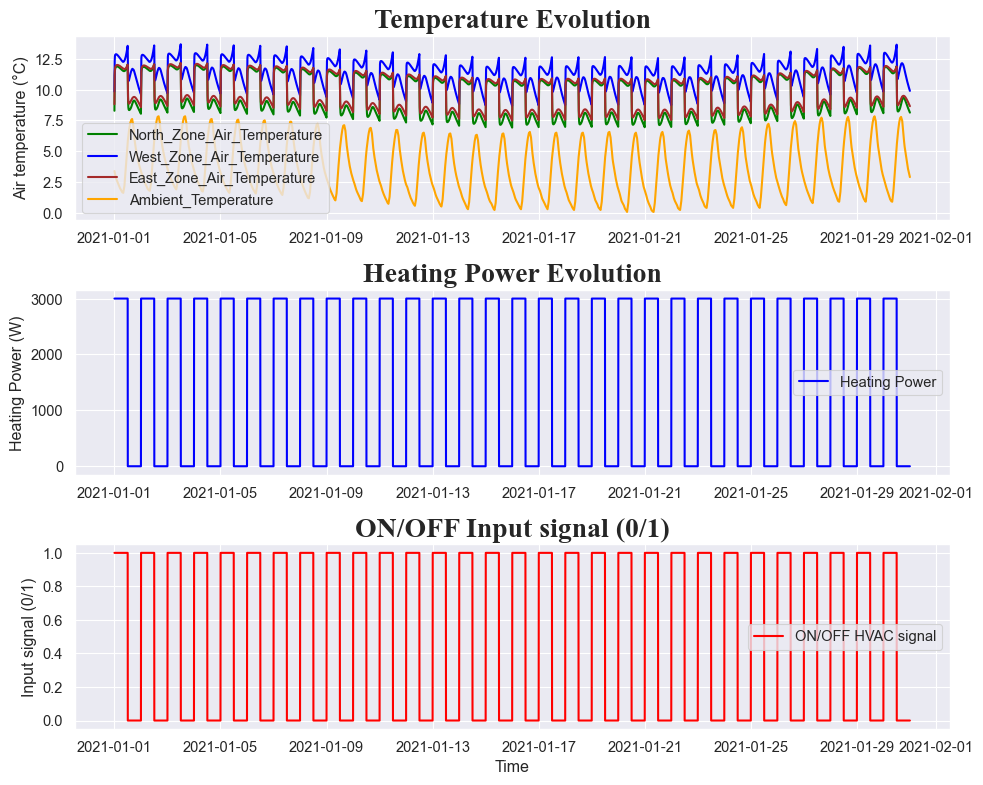

In [12]:
# Specify the path and filename and save the DataFrame to a new CSV file
file_path =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week3_parameter_freezing\DOF_change"
filename = f"{file_path}imulation_results_{timestamp}.csv"
filename2 = r'D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week3_parameter_freezing\DOF_change\Indoor_Temperatures2.csv'
# Specify the file path

df.to_csv(filename, index=False)
df.to_csv(filename2, index=False)


fig, axs = plt.subplots(3, 1, figsize=(10, 8), tight_layout=True)
minutes_to_plot = 2592000   # Define the number of minutes to plot

# Ensure that we have enough data to plot 200 minutes
if len(df) > minutes_to_plot:
    plot_data = df.iloc[:minutes_to_plot]
else:
    plot_data = df  # Not enough data, use what we have

# Plot T_int1, T_int2, T_int3, T_ext
for temp, color in zip(['North_Zone_Air_Temperature', 'West_Zone_Air_Temperature', 'East_Zone_Air_Temperature', 'Ambient_Temperature'], ['green', 'blue', 'brown', 'orange']):
    axs[0].plot(plot_data.index, plot_data[temp], color=color, linewidth=1.5, label=temp)
axs[0].set(ylabel='Temperature (°C)')
axs[0].legend(loc='best')
axs[0].set_ylabel('Air temperature (°C)')
axs[0].set_title('Temperature Evolution', fontname="Times New Roman", size=20, fontweight="bold")

# Plot P_hea1
axs[1].plot(plot_data.index, plot_data['Heating_Power'], color='blue', linewidth=1.5, label='Heating Power')
axs[1].set(ylabel='Heating Power (W)')
axs[1].legend(loc='best')
axs[1].set_ylabel('Heating Power (W)')
axs[1].set_title('Heating Power Evolution', fontname="Times New Roman", size=20, fontweight="bold")

# Plot P_hea2
axs[2].plot(plot_data.index, plot_data['Heating Input'], color='red', linewidth=1.5, label='ON/OFF HVAC signal')
axs[2].set(xlabel='Time', ylabel='P_hea2')
axs[2].legend(loc='best')
axs[2].set_ylabel('Input signal (0/1)')
axs[2].set_title('ON/OFF Input signal (0/1)', fontname="Times New Roman", size=20, fontweight="bold")

plt.show()

plt.show()

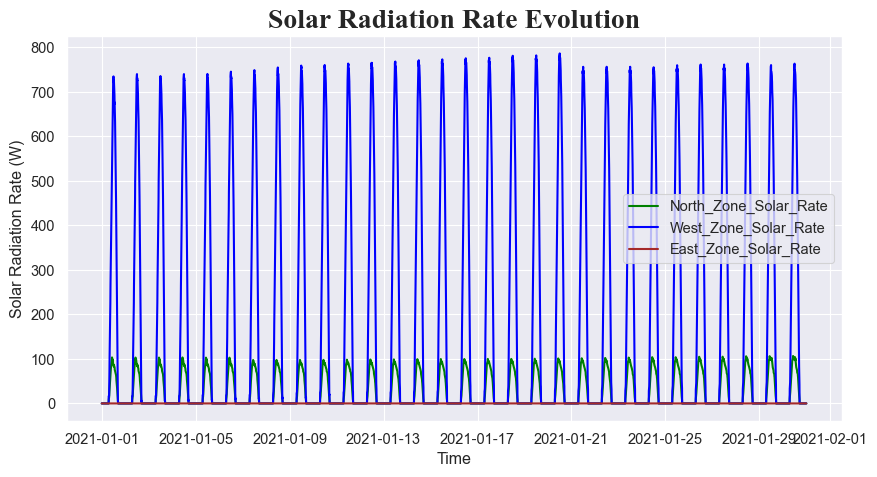

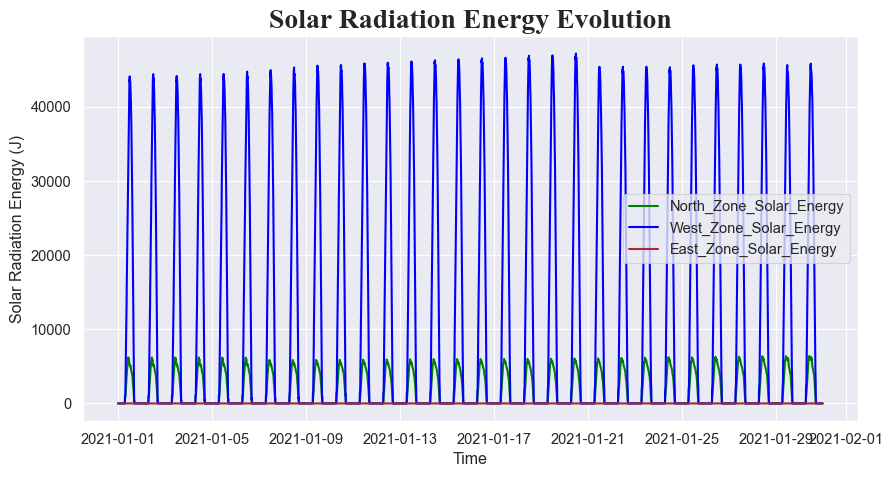

In [13]:
import matplotlib.pyplot as plt

# Plot Solar Radiation Rate
plt.figure(figsize=(10, 5))
for zone, color in zip(['North_Zone_Solar_Rate', 'West_Zone_Solar_Rate', 'East_Zone_Solar_Rate'], ['green', 'blue', 'brown']):
    plt.plot(plot_data.index, plot_data[zone], color=color, linewidth=1.5, label=zone)
plt.ylabel('Solar Radiation Rate (W)')
plt.xlabel('Time')
plt.legend(loc='best')
plt.title('Solar Radiation Rate Evolution', fontname="Times New Roman", size=20, fontweight="bold")
plt.show()

# Plot Solar Radiation Energy
plt.figure(figsize=(10, 5))
for zone, color in zip(['North_Zone_Solar_Energy', 'West_Zone_Solar_Energy', 'East_Zone_Solar_Energy'], ['green', 'blue', 'brown']):
    plt.plot(plot_data.index, plot_data[zone], color=color, linewidth=1.5, label=zone)
plt.ylabel('Solar Radiation Energy (J)')
plt.xlabel('Time')
plt.legend(loc='best')
plt.title('Solar Radiation Energy Evolution', fontname="Times New Roman", size=20, fontweight="bold")
plt.show()


<>:234: SyntaxWarning: invalid escape sequence '\P'
<>:234: SyntaxWarning: invalid escape sequence '\P'
C:\Users\USER\AppData\Local\Temp\ipykernel_4632\2655043718.py:234: SyntaxWarning: invalid escape sequence '\P'
  df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/solar/DOF_change/verification.csv', index=False)


[3.3825 3.375  3.3675 ... 2.903  2.8965 2.89  ]
[3.37813108e+03 2.87589506e+03 2.31770313e+03 8.55323027e+00
 1.30493775e+02 0.00000000e+00 6.34889421e+01 8.18428569e+01
 0.00000000e+00 7.91242541e-02]
C1: 3378.131081503255
C2: 2875.8950563293565
C3: 2317.703134079491
K12: 8.553230265389923
K10: 130.4937751284328
K23: 0.0
K20: 63.48894208926948
K30: 81.84285686272436
D1: 0.0
D2: 0.07912425410240087
RMSE for Zone 1: 2.21
RMSE for Zone 2: 3.75
RMSE for Zone 3: 2.77


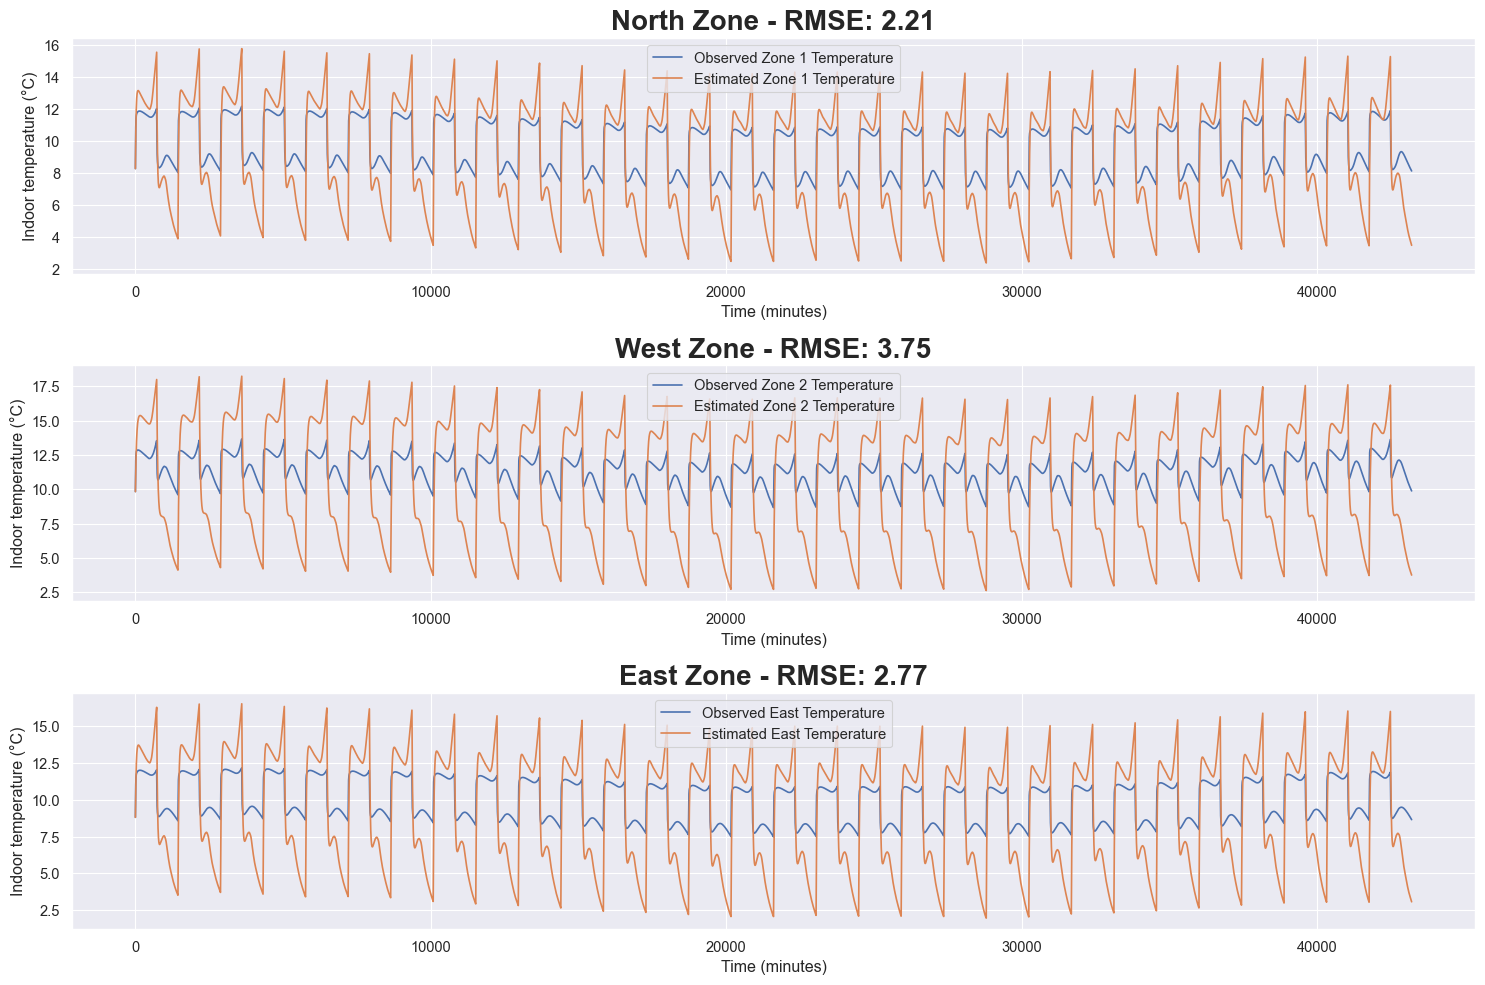

In [14]:


# Read the data from CSV files
#filename =  r"C:\Users\onyej\OneDrive\Desktop\Documents\Experiments Folder\modifiedversion\modifiedversion2\Resultssimulation_results_2024-06-08_02-07-16.csv"
df = pd.read_csv(filename)

# Define time step if not explicitly given (assuming uniform steps)
time = df['time_steps'].values

#I added
#df['time_steps'] = np.arange(len(df))  # Recreate time steps
#time = df['time_steps'].values  # Extract again

#print(f"Verification Data Total Points 1111: {len(time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {time[-1]}")
num_steps = len(time)
dt = np.median(np.diff(time))
dt=1



# Extracting data
T_outdoor = df['Ambient_Temperature'].values
print(T_outdoor)
zone1 = df['North_Zone_Air_Temperature'].values  
zone2 = df['West_Zone_Air_Temperature'].values 
zone3 = df['East_Zone_Air_Temperature'].values 
U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values

#new radiation power
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values

# Compute temperature derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)

# Initialize matrices for the least squares problem
num_params = 10 # C1, C2, C3, K12, K10, K23, K20, K30 , D1 , D2, D3
#num_params = 11
A = np.zeros((3 * num_steps, num_params))
b = np.zeros(3 * num_steps)

# Fill in the A matrix and b vector for each time step
for i in range(num_steps):
    '''A[3*i] = [
        dT1_dt[i], 0, 0, -(zone2[i] - zone1[i]) * dt, -(T_outdoor[i] - zone1[i]) * dt, 0, 0, 0,
        -NS1[i] * dt, 0, 0  # Solar absorption term for Zone 1
    ]'''
    A[3*i] = [
    dT1_dt[i], 0, 0,
    -(zone2[i] - zone1[i]) * dt, -(T_outdoor[i] - zone1[i]) * dt, 0, 0, 0,
    -NS1[i] * dt, 0 ]

    b[3*i] = U1[i] * dt  

    '''A[3*i + 1] = [
        0, dT2_dt[i], 0, -(zone1[i] - zone2[i]) * dt, 0, -(zone3[i] - zone2[i]) * dt,
        -(T_outdoor[i] - zone2[i]) * dt, 0, 0, -WS2[i] * dt, 0  # Solar absorption term for Zone 2
    ]'''
    A[3*i + 1] = [
    0, dT2_dt[i], 0,
    -(zone1[i] - zone2[i]) * dt, 0, -(zone3[i] - zone2[i]) * dt, -(T_outdoor[i] - zone2[i]) * dt, 0,
    0, -WS2[i] * dt ]

    b[3*i + 1] = U2[i] * dt  

    '''A[3*i + 2] = [
        0, 0, dT3_dt[i], 0, 0, -(zone2[i] - zone3[i]) * dt, 0, -(T_outdoor[i] - zone3[i]) * dt,
        0, 0, -ES3[i] * dt  # Solar absorption term for Zone 3
    ]'''
    A[3*i + 2] = [
    0, 0, dT3_dt[i],
    0, 0, -(zone2[i] - zone3[i]) * dt, 0, -(T_outdoor[i] - zone3[i]) * dt,
    0, 0  ]
    b[3*i + 2] = (U3[i] ) * dt  
#A[:, 8] *= 2500  # Strengthen NS1 contribution
#A[:, 9] *= 2500  # Strengthen WS2 contribution
#A[:, 10] *= 2500 # Strengthen ES3 contribution

# Solve the least squares problem with non-negative constraints
theta, rnorm = nnls(A, b)
#from numpy.linalg import lstsq
#theta, residuals, rank, s = lstsq(A, b, rcond=None)
#print(f"Residuals: {residuals}")

#print(f"Singular Values: {s}")

# Extract the identified parameters
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2, D3    = theta
C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2    = theta

print(theta)

# Print the identified parameters
print(f"C1: {C1}")
print(f"C2: {C2}")
print(f"C3: {C3}")
print(f"K12: {K12}")
print(f"K10: {K10}")
print(f"K23: {K23}")
print(f"K20: {K20}")
print(f"K30: {K30}")
print(f"D1: {D1}")
print(f"D2: {D2}")
#print(f"D3: {D3}")


# Round each value to one decimal place
data_dict = {
    'K12': round(K12, 1), 
    'K23': round(K23, 1), 
    'K10': round(K10, 1), 
    'K20': round(K20, 1), 
    'K30': round(K30, 1), 
    'C1': round(C1, 1), 
    'C2': round(C2, 1), 
    'C3': round(C3, 1),
    'D1': round(D1, 1),
    'D2': round(D2, 1),
 #   'D3': round(D3, 1)
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame([data_dict])

# Specify the file path
Rc_Parameters = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\solar\DOF_change\Parameter_Estimates.csv"

# Check if file exists and is not empty
if os.path.isfile(Rc_Parameters) and os.path.getsize(Rc_Parameters) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(Rc_Parameters, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(Rc_Parameters, mode='w', header=True, index=False)
    
#K12=K12+1000  
###############################################################################################################################    
D3=0 #just for measuring
######################################################################################################################    
# Calculate the estimated temperatures
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]  # Initial temperature for zone1
estimated_zone2[0] = zone2[0]  # Initial temperature for zone2
estimated_zone3[0] = zone3[0]  # Initial temperature for zone3

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (K12*(zone2[i-1] - estimated_zone1[i-1]) + K10*(T_outdoor[i-1] - estimated_zone1[i-1]) + U1[i-1] + D1*NS1[i-1] )/C1 * dt 
    estimated_zone2[i] = estimated_zone2[i-1] + (K12*(zone1[i-1] - estimated_zone2[i-1]) + K23*(zone3[i-1] - estimated_zone2[i-1]) + K20*(T_outdoor[i-1] - estimated_zone2[i-1]) + U2[i-1] + D2*WS2[i-1] )/C2 * dt 
    estimated_zone3[i] = estimated_zone3[i-1] + (K23*(zone2[i-1] - estimated_zone3[i-1]) + K30*(T_outdoor[i-1] - estimated_zone3[i-1]) + U3[i-1]  + D3 * ES3[i-1])/C3 * dt 
    
    
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")


# Round each value to one decimal place
RMSE = {
    'RMSE Zone 1': rmse_y1, 
    'RMSE Zone 2': rmse_y2, 
    'RMSE Zone 3': rmse_y3
}

df = pd.DataFrame([RMSE])

# Specify the file path
RMSE = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\solar\DOF_change\RMSE.csv"


# Check if file exists and is not empty
if os.path.isfile(RMSE) and os.path.getsize(RMSE) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(RMSE, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(RMSE, mode='w', header=True, index=False)




###########################################################################################################################################################################################################################
# Assuming `time` is an array or series that increments per minute, we trim all arrays to some number of minutes
minutes_to_plot = 2592000
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    # Not enough data, use what we have
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3
    
    
    
###########################################################################################################################################################################################################################    

# Create a DataFrame and save the verification data to a CSV file
data = {
    'Time': plot_time,
    'Observed_Temperature_Zone_1': plot_zone1,
    'Estimated_Temperature_Zone_1': plot_estimated_zone1,
    'Observed_Temperature_Zone_2': plot_zone2,
    'Estimated_Temperature_Zone_2': plot_estimated_zone2,
    'Observed_Temperature_Zone_3': plot_zone3,
    'Estimated_Temperature_Zone_3': plot_estimated_zone3,
    'Outdoor_Tmperature': T_outdoor
}
df = pd.DataFrame(data)
# Save to CSV
#print(f"Verification Data Total Points: {len(plot_time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {plot_time[-1]}")

df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/solar/DOF_change/verification.csv', index=False)



##########################################################################################################################################################################################################################

#Plotting the results
plt.figure(figsize=(15, 10))
#plot_time=df
# North Zone
plt.subplot(3, 1, 1)
plt.plot(plot_time, plot_zone1, label='Observed Zone 1 Temperature')
plt.plot(plot_time, plot_estimated_zone1, label='Estimated Zone 1 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(plot_time, plot_zone2, label='Observed Zone 2 Temperature')
plt.plot(plot_time, plot_estimated_zone2, label='Estimated Zone 2 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(plot_time, plot_zone3, label='Observed East Temperature')
plt.plot(plot_time, plot_estimated_zone3, label='Estimated East Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()
#print(f"Total data points available: {len(time)}")#
#print(f"First time value: {time[0]}, Last time value: {time[-1]}")


<>:239: SyntaxWarning: invalid escape sequence '\P'
<>:239: SyntaxWarning: invalid escape sequence '\P'
C:\Users\USER\AppData\Local\Temp\ipykernel_4632\2257610210.py:239: SyntaxWarning: invalid escape sequence '\P'
  df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/solar/DOF_change/verification.csv', index=False)


[3.3825 3.375  3.3675 ... 2.903  2.8965 2.89  ]
Estimated Parameters:
C1: 3378.1, C2: 2875.9, C3: 2317.7
K12: 8.6, K10: 130.5, K23: 0.0, K20: 63.5, K30: 81.8
D1: 0.000, D2: 0.079
[3.37813108e+03 2.87589506e+03 2.31770313e+03 8.55323027e+00
 1.30493775e+02 0.00000000e+00 6.34889421e+01 8.18428569e+01
 0.00000000e+00 7.91242541e-02]
C1: 3378.131081503255
C2: 2875.8950563293565
C3: 2317.703134079491
K12: 8.553230265389923
K10: 130.4937751284328
K23: 0.0
K20: 63.48894208926948
K30: 81.84285686272436
D1: 0.0
D2: 0.07912425410240087
RMSE for Zone 1: 2.21
RMSE for Zone 2: 3.75
RMSE for Zone 3: 2.77


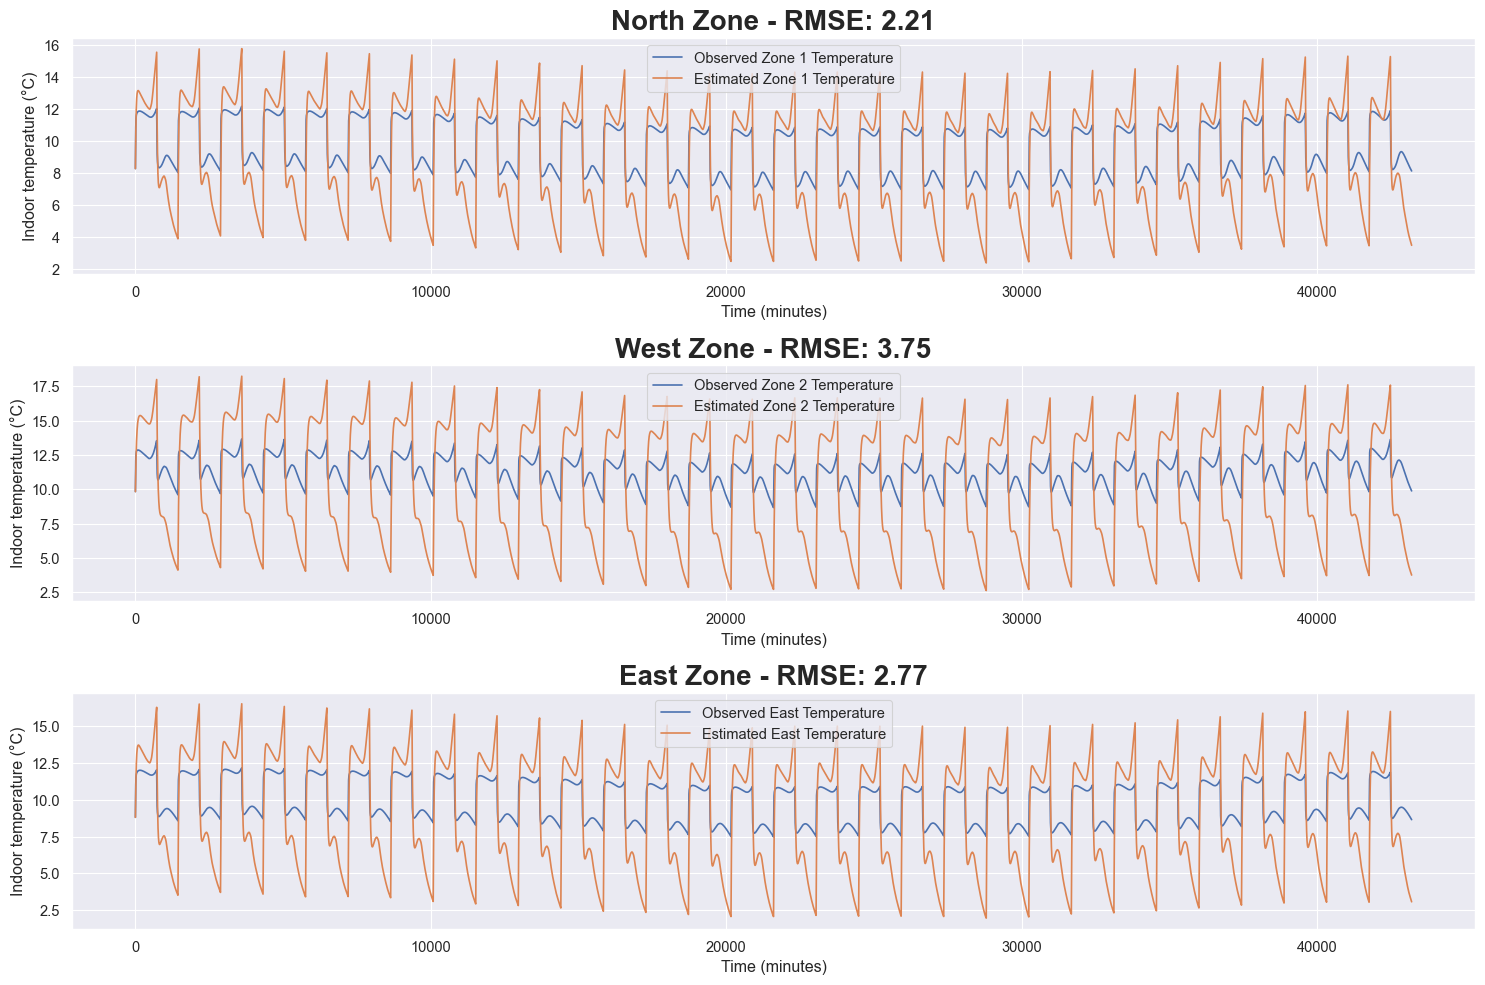

In [15]:


# Read the data from CSV files
#filename =  r"C:\Users\onyej\OneDrive\Desktop\Documents\Experiments Folder\modifiedversion\modifiedversion2\Resultssimulation_results_2024-06-08_02-07-16.csv"
df = pd.read_csv(filename)

# Define time step if not explicitly given (assuming uniform steps)
time = df['time_steps'].values

#I added
#df['time_steps'] = np.arange(len(df))  # Recreate time steps
#time = df['time_steps'].values  # Extract again

#print(f"Verification Data Total Points 1111: {len(time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {time[-1]}")
num_steps = len(time)
dt = np.median(np.diff(time))
dt=1



# Extracting data
T_outdoor = df['Ambient_Temperature'].values
print(T_outdoor)
zone1 = df['North_Zone_Air_Temperature'].values  
zone2 = df['West_Zone_Air_Temperature'].values 
zone3 = df['East_Zone_Air_Temperature'].values 
U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values

#new radiation power
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values

# Compute temperature derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)

# Initialize matrices for the least squares problem
num_params = 10 # C1, C2, C3, K12, K10, K23, K20, K30 , D1 , D2, D3
#num_params = 11

num_params = 10
A = np.zeros((3 * num_steps, num_params))
b = np.zeros(3 * num_steps)

for i in range(num_steps):
    # Zone 1
    A[3*i] = [
        dT1_dt[i], 0, 0,
        -(zone2[i] - zone1[i]),   # K12
        -(T_outdoor[i] - zone1[i]),  # K10
        0, 0, 0,
        -NS1[i], 0  # D1
    ]
    b[3*i] = U1[i]

    # Zone 2
    A[3*i + 1] = [
        0, dT2_dt[i], 0,
        -(zone1[i] - zone2[i]),   # K12
        0,
        -(zone3[i] - zone2[i]),   # K23
        -(T_outdoor[i] - zone2[i]),  # K20
        0,
        0, -WS2[i]  # D2
    ]
    b[3*i + 1] = U2[i]

    # Zone 3
    A[3*i + 2] = [
        0, 0, dT3_dt[i],
        0,
        0,
        -(zone2[i] - zone3[i]),  # K23
        0,
        -(T_outdoor[i] - zone3[i]),  # K30
        0, 0
    ]
    b[3*i + 2] = U3[i]

# Solve NNLS
theta, rnorm = nnls(A, b)
C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = theta
print("Estimated Parameters:")
print(f"C1: {C1:.1f}, C2: {C2:.1f}, C3: {C3:.1f}")
print(f"K12: {K12:.1f}, K10: {K10:.1f}, K23: {K23:.1f}, K20: {K20:.1f}, K30: {K30:.1f}")
print(f"D1: {D1:.3f}, D2: {D2:.3f}")
#from numpy.linalg import lstsq
#theta, residuals, rank, s = lstsq(A, b, rcond=None)
#print(f"Residuals: {residuals}")

#print(f"Singular Values: {s}")

# Extract the identified parameters
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2, D3    = theta
C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2    = theta

print(theta)

# Print the identified parameters
print(f"C1: {C1}")
print(f"C2: {C2}")
print(f"C3: {C3}")
print(f"K12: {K12}")
print(f"K10: {K10}")
print(f"K23: {K23}")
print(f"K20: {K20}")
print(f"K30: {K30}")
print(f"D1: {D1}")
print(f"D2: {D2}")
#print(f"D3: {D3}")


# Round each value to one decimal place
data_dict = {
    'K12': round(K12, 1), 
    'K23': round(K23, 1), 
    'K10': round(K10, 1), 
    'K20': round(K20, 1), 
    'K30': round(K30, 1), 
    'C1': round(C1, 1), 
    'C2': round(C2, 1), 
    'C3': round(C3, 1),
    'D1': round(D1, 1),
    'D2': round(D2, 1),
 #   'D3': round(D3, 1)
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame([data_dict])

# Specify the file path
Rc_Parameters = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\solar\DOF_change\Parameter_Estimates.csv"

# Check if file exists and is not empty
if os.path.isfile(Rc_Parameters) and os.path.getsize(Rc_Parameters) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(Rc_Parameters, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(Rc_Parameters, mode='w', header=True, index=False)
    
#K12=K12+1000  
###############################################################################################################################    
D3=0 #just for measuring
######################################################################################################################    
# Calculate the estimated temperatures
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]  # Initial temperature for zone1
estimated_zone2[0] = zone2[0]  # Initial temperature for zone2
estimated_zone3[0] = zone3[0]  # Initial temperature for zone3

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (K12*(zone2[i-1] - estimated_zone1[i-1]) + K10*(T_outdoor[i-1] - estimated_zone1[i-1]) + U1[i-1] + D1*NS1[i-1] )/C1 * dt 
    estimated_zone2[i] = estimated_zone2[i-1] + (K12*(zone1[i-1] - estimated_zone2[i-1]) + K23*(zone3[i-1] - estimated_zone2[i-1]) + K20*(T_outdoor[i-1] - estimated_zone2[i-1]) + U2[i-1] + D2*WS2[i-1] )/C2 * dt 
    estimated_zone3[i] = estimated_zone3[i-1] + (K23*(zone2[i-1] - estimated_zone3[i-1]) + K30*(T_outdoor[i-1] - estimated_zone3[i-1]) + U3[i-1]  + D3 * ES3[i-1])/C3 * dt 
    
    
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")


# Round each value to one decimal place
RMSE = {
    'RMSE Zone 1': rmse_y1, 
    'RMSE Zone 2': rmse_y2, 
    'RMSE Zone 3': rmse_y3
}

df = pd.DataFrame([RMSE])

# Specify the file path
RMSE = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\solar\DOF_change\RMSE.csv"


# Check if file exists and is not empty
if os.path.isfile(RMSE) and os.path.getsize(RMSE) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(RMSE, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(RMSE, mode='w', header=True, index=False)




###########################################################################################################################################################################################################################
# Assuming `time` is an array or series that increments per minute, we trim all arrays to some number of minutes
minutes_to_plot = 2592000
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    # Not enough data, use what we have
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3
    
    
    
###########################################################################################################################################################################################################################    

# Create a DataFrame and save the verification data to a CSV file
data = {
    'Time': plot_time,
    'Observed_Temperature_Zone_1': plot_zone1,
    'Estimated_Temperature_Zone_1': plot_estimated_zone1,
    'Observed_Temperature_Zone_2': plot_zone2,
    'Estimated_Temperature_Zone_2': plot_estimated_zone2,
    'Observed_Temperature_Zone_3': plot_zone3,
    'Estimated_Temperature_Zone_3': plot_estimated_zone3,
    'Outdoor_Tmperature': T_outdoor
}
df = pd.DataFrame(data)
# Save to CSV
#print(f"Verification Data Total Points: {len(plot_time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {plot_time[-1]}")

df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/solar/DOF_change/verification.csv', index=False)



##########################################################################################################################################################################################################################

#Plotting the results
plt.figure(figsize=(15, 10))
#plot_time=df
# North Zone
plt.subplot(3, 1, 1)
plt.plot(plot_time, plot_zone1, label='Observed Zone 1 Temperature')
plt.plot(plot_time, plot_estimated_zone1, label='Estimated Zone 1 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(plot_time, plot_zone2, label='Observed Zone 2 Temperature')
plt.plot(plot_time, plot_estimated_zone2, label='Estimated Zone 2 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(plot_time, plot_zone3, label='Observed East Temperature')
plt.plot(plot_time, plot_estimated_zone3, label='Estimated East Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()
#print(f"Total data points available: {len(time)}")#
#print(f"First time value: {time[0]}, Last time value: {time[-1]}")
